Connect Google Drive


**Assignment Title:** CNN Development on Custom Dataset  

This project builds a Convolutional Neural Network (CNN) using PyTorch to classify fruit images into five classes: apple, banana, mango, orange, and strawberry.

## Mount Google Drive & Set Dataset Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dir = "/content/drive/MyDrive/dataset"

## Check dataset

In [4]:
import os

print(os.listdir(data_dir))

['test', 'val', 'train']


## Import Libraries

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 3. Data Preprocessing

The images are resized to 128 × 128 pixels and converted into tensors before being fed into the CNN model.

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

## 4. Load Dataset and Create DataLoaders

The dataset is loaded using `ImageFolder`, and DataLoaders are created for training, validation, and testing.

In [8]:
train_dataset = datasets.ImageFolder(root=data_dir + "/train", transform=transform)
val_dataset = datasets.ImageFolder(root=data_dir + "/val", transform=transform)
test_dataset = datasets.ImageFolder(root=data_dir + "/test", transform=transform)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 5. Verify Dataset and DataLoader

In this section, the dataset is checked to ensure it is loaded correctly.  
The class names are printed, and one batch of images and labels is inspected.

This step helps confirm:
- The correct number of classes
- Proper label assignment
- Correct image shape and batch size

In [10]:
print(train_dataset.classes)

['apple', 'banana', 'mango', 'orange', 'strawberry']


In [11]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


## 6. Define CNN Architecture

In this section, a Convolutional Neural Network (CNN) model is defined.

The model consists of:
- Two convolutional layers for feature extraction
- ReLU activation function to introduce non-linearity
- Max pooling layers to reduce spatial dimensions
- Fully connected layers for classification

The input image size is 128 × 128, and the model outputs predictions for 5 classes.

In [ ]:
# Define a simple CNN model
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolution Layer 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        # Convolution Layer 2
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(32 * 32 * 32, 128)  # after pooling
        self.fc2 = nn.Linear(128, 5)  # 5 classes

    def forward(self, x):
        # First conv layer
        x = self.pool(self.relu(self.conv1(x)))

        # Second conv layer
        x = self.pool(self.relu(self.conv2(x)))

        # Flatten
        x = x.view(-1, 32 * 32 * 32)

        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Create model instance and display architecture

In [ ]:
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## 7. Define Loss Function and Optimizer

In this section, the loss function and optimizer are defined.

- CrossEntropyLoss is used because this is a multi-class classification problem.
- Adam optimizer is used to update model weights efficiently during training.

The learning rate is set to 0.001 to control how fast the model learns.

In [ ]:
# Loss function (for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Optimizer
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Set Device (CPU/GPU)

In this section, the device for training is selected.

If a GPU is available, the model will use it for faster computation.  
Otherwise, the model will run on CPU.

The model is then moved to the selected device.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(device)

cpu


## 9. Define Training Function

In this section, a function is defined to train the CNN model.

The function performs:
- Training on the training dataset
- Validation on the validation dataset after each epoch
- Calculation of loss and accuracy for both training and validation sets

The model parameters are updated using backpropagation and the optimizer.

The function also stores loss and accuracy values for plotting performance graphs later.

In [ ]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    # Lists to store loss and accuracy
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        # ----- Training mode -----
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Store training loss
            running_train_loss += loss.item()

            # Calculate training accuracy
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_acc = 100 * correct_train / total_train

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # ----- Validation mode -----
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_acc = 100 * correct_val / total_val

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        # Print result for each epoch
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_acc:.2f}%")
        print(f"Val Loss:   {epoch_val_loss:.4f}, Val Accuracy:   {epoch_val_acc:.2f}%")
        print("-" * 50)

    return train_losses, val_losses, train_accuracies, val_accuracies

## 10. Train the Model

In this section, the training function is executed.

The model is trained for 10 epochs using the training dataset, and its performance is evaluated on the validation dataset after each epoch.

The loss and accuracy values for both training and validation sets are stored for further analysis and visualization.

In [ ]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, device, epochs=10
)

Epoch [1/10]
Train Loss: 1.1015, Train Accuracy: 56.57%
Val Loss:   0.5302, Val Accuracy:   82.88%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.2850, Train Accuracy: 91.92%
Val Loss:   0.2745, Val Accuracy:   84.93%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.0659, Train Accuracy: 98.79%
Val Loss:   0.3479, Val Accuracy:   77.40%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.0218, Train Accuracy: 99.39%
Val Loss:   0.0419, Val Accuracy:   100.00%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.0198, Train Accuracy: 99.39%
Val Loss:   0.2874, Val Accuracy:   85.62%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.0053, Train Accuracy: 100.00%
Val Loss:   0.0157, Val Accuracy:   100.00%
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.0021, Train Accuracy: 100.00%
Val Loss:   0.0320, Val Accuracy:   100.

## 11. Visualize Training Performance

In this section, the training and validation performance of the model is visualized using graphs.

Two plots are created:
- Loss curve: shows how the training and validation loss change over epochs
- Accuracy curve: shows how the training and validation accuracy improve over time

These graphs help in understanding how well the model is learning and whether it is overfitting or underfitting.

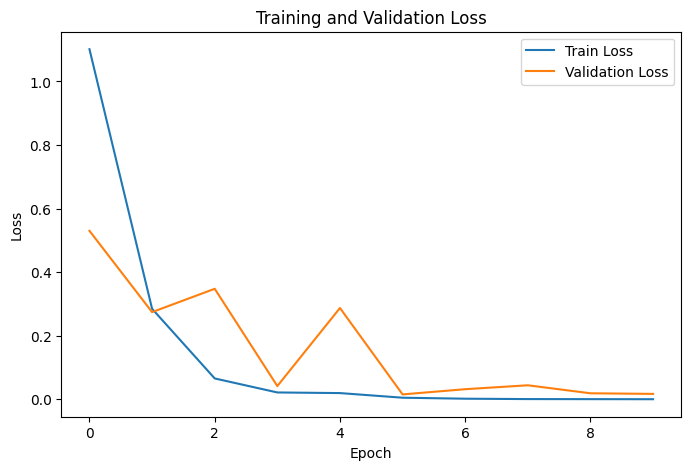

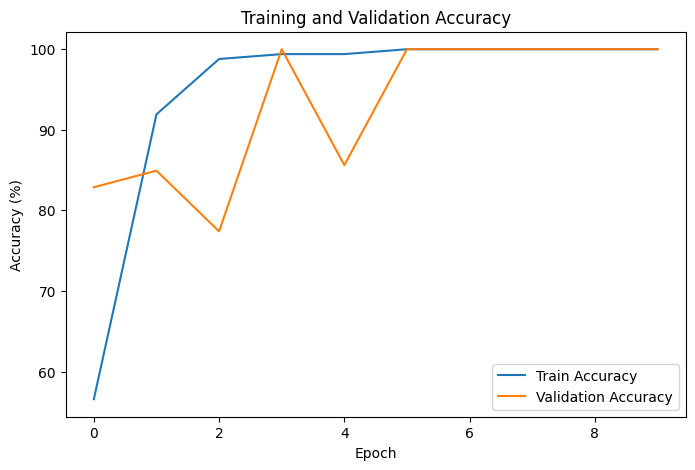

In [ ]:
# Plot training and validation loss and accuracy
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

## 12. Evaluate Model on Test Set

In this section, the trained model is evaluated using the test dataset.

The model makes predictions on unseen test images, and the predicted labels are collected along with the true labels.

These predictions will be used to calculate performance metrics such as accuracy, precision, recall, F1-score, and to generate a confusion matrix.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

## 13. Classification Report

This section calculates and displays the classification metrics for the test dataset.

The metrics include:
- **Precision**: the ability of the model to not label a negative sample as positive
- **Recall**: the ability of the model to find all positive samples
- **F1-score**: the harmonic mean of precision and recall

The report provides per-class metrics using the true labels and the predicted labels.

In [ ]:
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
       mango       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
  strawberry       1.00      1.00      1.00        30

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



## 14. Confusion Matrix

In this section, a confusion matrix is created to visualize the performance of the model on the test dataset.

- The confusion matrix shows the number of correct and incorrect predictions for each class.
- The rows represent the actual labels, and the columns represent the predicted labels.
- Perfect diagonal values indicate correct predictions, while off-diagonal values indicate misclassifications.

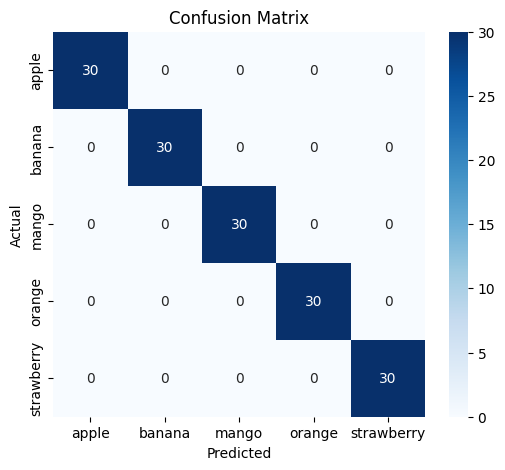

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 13. Conclusion

In this project, a custom CNN was developed using PyTorch to classify fruit images into five categories.  
The model was successfully trained, validated, and tested using a structured image dataset.

The model achieved excellent results in terms of accuracy, precision, recall, and F1-score.  
This project demonstrates that CNNs are highly effective for image classification tasks when trained on clean and organized datasets.

For future work, the model can be improved by:
- using more complex datasets
- applying data augmentation
- experimenting with batch normalization and dropout
- testing deeper CNN architectures

## 15. Save Trained Model

In this section, the trained CNN model weights are saved in `.pth` format for future use.

Saving the model allows to:
- Load it later without retraining
- Share it as part of your assignment submission
- Use it for inference on new images

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/cnn_model.pth")